# Data Overview

This notebook provides an overview of the Fake and Real News dataset used for training the news credibility verification system.

**Dataset source**: [Kaggle — Fake and Real News Dataset](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset) by Clément Bisaillon

**Contents**:
1. Data loading and initial inspection
2. Class distribution
3. Duplicate analysis
4. Text length distributions (words, sentences, characters)
5. Summary of preprocessing decisions

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

/Users/aoleszkiewicz/dev/factlens/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading

The dataset consists of two separate CSV files: `True.csv` (real news from Reuters) and `Fake.csv` (fake news from various sources). Each file contains columns: `title`, `text`, `subject`, `date`.

In [2]:
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

true_df = pd.read_csv(f"{path}/True.csv")
fake_df = pd.read_csv(f"{path}/Fake.csv")

true_df["label"] = 1
fake_df["label"] = 0

raw_df = pd.concat([true_df, fake_df], ignore_index=True)

print(f"True articles: {len(true_df):,}")
print(f"Fake articles: {len(fake_df):,}")
print(f"Total: {len(raw_df):,}")

True articles: 21,417
Fake articles: 23,481
Total: 44,898


In [3]:
print("Columns:", list(raw_df.columns))
print(f"\nShape: {raw_df.shape}")
print(f"\nMissing values:\n{raw_df.isnull().sum()}")
print(f"\nEmpty text rows: {(raw_df['text'].str.strip() == '').sum()}")
raw_df.head(3)

Columns: ['title', 'text', 'subject', 'date', 'label']

Shape: (44898, 5)

Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Empty text rows: 631


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1


In [ ]:
print("Sample REAL article:")
print(raw_df[raw_df["label"] == 1]["text"].iloc[0][:500])
print("\nSample FAKE article:")
print(raw_df[raw_df["label"] == 0]["text"].iloc[0][:500])

Sample REAL article:
WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they retur

Sample FAKE article:
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  Presi

### Metadata columns

The `subject` and `date` columns are metadata that could introduce data leakage. The `subject` categories differ completely between classes, making them a trivial shortcut for classification. We drop `title`, `subject`, and `date` to force the model to learn from article content only.

In [5]:
print("Subject distribution by class:\n")
print("REAL subjects:")
print(true_df["subject"].value_counts().to_string())
print("\nFAKE subjects:")
print(fake_df["subject"].value_counts().to_string())

Subject distribution by class:

REAL subjects:
subject
politicsNews    11272
worldnews       10145

FAKE subjects:
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778


## 2. Class Distribution

The dataset is slightly imbalanced. We keep both classes as-is since the imbalance is mild (< 10% difference).

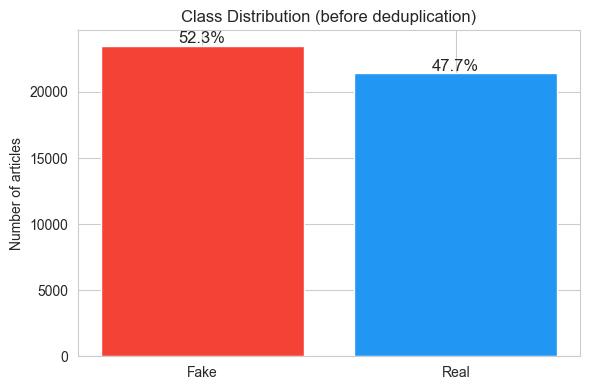


Imbalance ratio: 1.10:1


In [6]:
label_counts = raw_df["label"].value_counts().rename({0: "Fake", 1: "Real"})
label_pcts = (label_counts / len(raw_df) * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(label_counts.index, label_counts.values, color=["#F44336", "#2196F3"])
for bar, pct in zip(bars, label_pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{pct}%", ha="center", fontsize=12)
ax.set_ylabel("Number of articles")
ax.set_title("Class Distribution (before deduplication)")
plt.tight_layout()
plt.show()

print(f"\nImbalance ratio: {label_counts.max() / label_counts.min():.2f}:1")

## 3. Duplicate Analysis

Duplicates inflate performance metrics and must be removed before train/test splitting to prevent data leakage between splits.

In [7]:
# Drop metadata columns for content-based analysis
raw_df.drop(columns=["title", "subject", "date"], inplace=True)

n_duplicates = raw_df.duplicated().sum()
pct_duplicates = n_duplicates / len(raw_df) * 100

print(f"Exact duplicates: {n_duplicates:,} ({pct_duplicates:.1f}% of dataset)")

# Check class distribution of duplicates
dup_mask = raw_df.duplicated(keep=False)
dup_by_class = raw_df[dup_mask]["label"].value_counts().rename({0: "Fake", 1: "Real"})
print(f"\nDuplicates by class:\n{dup_by_class.to_string()}")

Exact duplicates: 6,251 (13.9% of dataset)

Duplicates by class:
label
Fake    10954
Real      437


In [8]:
df = raw_df.drop_duplicates().reset_index(drop=True)

print(f"Before deduplication: {len(raw_df):,}")
print(f"After deduplication:  {len(df):,}")
print(f"Removed: {len(raw_df) - len(df):,} rows")

Before deduplication: 44,898
After deduplication:  38,647
Removed: 6,251 rows


## 4. Text Length Distributions

Understanding length distributions helps identify outliers (scraping artifacts, URL-only articles) and set appropriate sequence length limits for the BiLSTM model.

In [ ]:
df["word_count"] = df["text"].str.split().str.len()
df["char_count"] = df["text"].str.len()
df["sentence_count"] = df["text"].str.count(r"[.!?]+")

length_stats = df.groupby("label")[["word_count", "char_count", "sentence_count"]].describe().round(1)
length_stats.index = length_stats.index.map({0: "Fake", 1: "Real"})
length_stats

word_count                                                 char_count  \
           count   mean    std  min    25%    50%    75%     max      count   
label                                                                         
Fake     17455.0  425.3  355.2  0.0  277.0  376.0  503.0  8135.0    17455.0   
Real     21192.0  384.8  273.8  0.0  147.0  359.0  523.0  5172.0    21192.0   

               ...                  sentence_count                         \
         mean  ...     75%      max          count  mean   std  min   25%   
label          ...                                                          
Fake   2549.8  ...  3005.5  51794.0        17455.0  23.1  20.1  0.0  13.0   
Real   2378.4  ...  3226.2  29781.0        21192.0  20.8  15.9  0.0   8.0   

                          
        50%   75%    max  
label                     
Fake   20.0  28.0  772.0  
Real   18.0  29.0  337.0  

[2 rows x 24 columns]

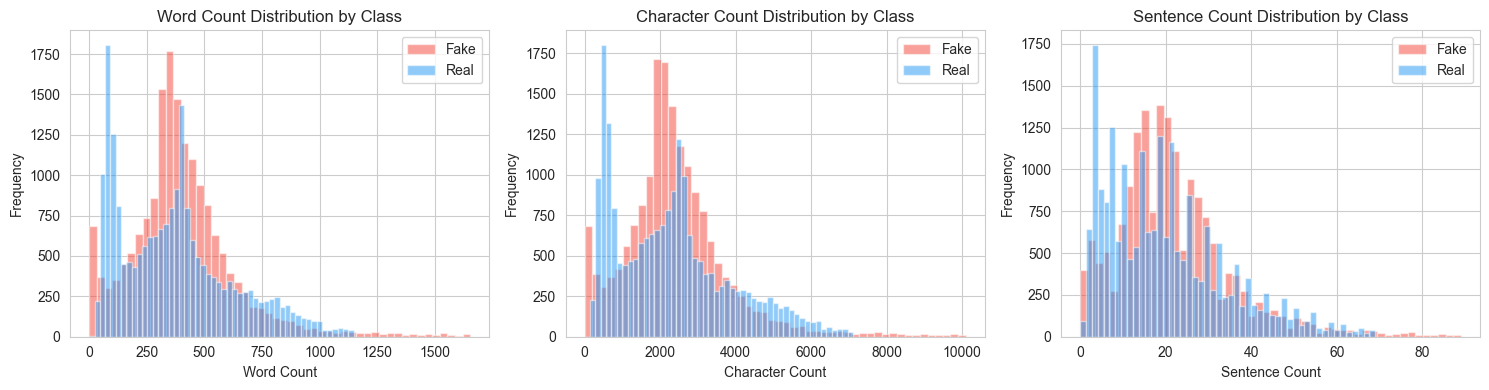

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes, 
    ["word_count", "char_count", "sentence_count"],
    ["Word Count", "Character Count", "Sentence Count"]):
    
    for label, color, name in [(0, "#F44336", "Fake"), (1, "#2196F3", "Real")]:
        subset = df[df["label"] == label][col]
        ax.hist(subset, bins=50, alpha=0.5, color=color, label=name,
                range=(0, subset.quantile(0.99)))
    ax.set_xlabel(title)
    ax.set_ylabel("Frequency")
    ax.set_title(f"{title} Distribution by Class")
    ax.legend()

plt.tight_layout()
plt.show()

Both classes have similar length distributions, with fake articles being slightly longer on average. The distributions are right-skewed, with a small number of very long articles.

In [11]:
short = df[df["word_count"] < 10]
print(f"Articles with < 10 words: {len(short)} ({len(short)/len(df)*100:.2f}%)")
print(f"  Fake: {(short['label'] == 0).sum()}")
print(f"  Real: {(short['label'] == 1).sum()}")

very_long = df[df["word_count"] > 3000]
print(f"\nArticles with > 3000 words: {len(very_long)} ({len(very_long)/len(df)*100:.2f}%)")
print(f"  Fake: {(very_long['label'] == 0).sum()}")
print(f"  Real: {(very_long['label'] == 1).sum()}")

Articles with < 10 words: 164 (0.42%)
  Fake: 163
  Real: 1

Articles with > 3000 words: 60 (0.16%)
  Fake: 55
  Real: 5


Very short articles (< 10 words) are likely scraping artifacts or URL-only entries that provide insufficient content for the model. These will be filtered out during the cleaning pipeline.

Very long articles will not be dropped — they will be truncated at the model's maximum sequence length during tokenization, preserving their content signal.

## 5. Summary

| Finding | Count | Action |
|---------|-------|--------|
| Total raw articles | ~44,898 | — |
| Exact duplicates | ~6,251 (13.9%) | Remove with `drop_duplicates()` |
| Empty/near-empty text | ~6 rows | Removed by deduplication or short-article filter |
| Short articles (< 10 words) | ~170 (0.4%) | Filter out — insufficient content |
| Long articles (> 3000 words) | Small % | Keep — truncate at model max sequence length |
| `subject` column | Perfectly class-correlated | Drop — data leakage |
| `title`, `date` columns | Metadata | Drop — not using for content classification |

**Next step**: Leakage analysis (notebook 02) to identify metadata artifacts in the article text itself.